In [1]:
import pandas as pd

In [2]:
df_cafe = pd.read_csv("C:/DSML/Jobs/2026/Internship/SkillAudit/CafeProject/data/processed/dirty_cafe_sales_cleaned.csv")

In [3]:
df_cafe.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,calculated_total
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,12.0
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,4.0
3,TXN_7034554,Salad,2,5.0,10.0,Unknown,Unknown,2023-04-27,10.0
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0


In [4]:
# Convert date time
df_cafe['transaction_date'] = pd.to_datetime(
    df_cafe['transaction_date'],
    errors = 'coerce'
)

## Dataset Overview

In [5]:
# Dataset dimensions
df_cafe.shape

(10000, 9)

In [6]:
# Dataset Statistics
df_cafe.describe(include='all')

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,calculated_total
count,10000,10000,10000.000000,10000.000000,10000.000000,10000,10000,9540,9006.000000
unique,10000,9,NaN,NaN,NaN,4,3,NaN,NaN
top,TXN_1961373,Juice,NaN,NaN,NaN,Unknown,Unknown,NaN,NaN
freq,1,1171,NaN,NaN,NaN,3178,3961,NaN,NaN
mean,NaN,NaN,3.025800,2.947050,8.930450,NaN,NaN,2023-07-01 23:00:31.698113280,8.936098
min,NaN,NaN,1.000000,1.000000,1.000000,NaN,NaN,2023-01-01 00:00:00,1.000000
25%,NaN,NaN,2.000000,2.000000,4.000000,NaN,NaN,2023-04-01 00:00:00,4.000000
50%,NaN,NaN,3.000000,3.000000,8.000000,NaN,NaN,2023-07-02 00:00:00,8.000000
75%,NaN,NaN,4.000000,4.000000,12.000000,NaN,NaN,2023-10-02 00:00:00,12.000000
max,NaN,NaN,8.000000,5.000000,25.000000,NaN,NaN,2023-12-31 00:00:00,25.000000


In [ ]:
# Numerical Statistics
df_cafe['quantity'].describe()
df_cafe['price_per_unit'].describe()
df_cafe['total_spent'].describe()

In [35]:
# Unique values
for col in df_cafe.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df_cafe[col].unique())


transaction_id:
['TXN_1961373' 'TXN_4977031' 'TXN_4271903' ... 'TXN_5255387' 'TXN_7695629'
 'TXN_6170729']

item:
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'Unknown' 'Sandwich' 'Juice'
 'Tea']

payment_method:
['Credit Card' 'Cash' 'Unknown' 'Digital Wallet']

location:
['Takeaway' 'In-store' 'Unknown']


In [37]:
# Checking for data range

print("Start Date;", df_cafe['transaction_date'].min())
print("Last Date;", df_cafe['transaction_date'].max())

Start Date; 2023-01-01 00:00:00
Last Date; 2023-12-31 00:00:00


## Item/Product Analysis

In [40]:
# Transactions per item

df_cafe.groupby('item')['transaction_id'].count().sort_values(ascending=False)

item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Unknown      969
Name: transaction_id, dtype: int64

In [46]:
# Total quantity per item

quantity_by_item = df_cafe.groupby('item')['quantity'].sum().sort_values(ascending=False)
print(revenue_by_item)

item
Coffee      3551
Juice       3514
Salad       3475
Cake        3471
Sandwich    3441
Smoothie    3342
Tea         3310
Cookie      3238
Unknown     2916
Name: quantity, dtype: int64


In [5]:
# Revenue per item

revenue_by_item = df_cafe.groupby('item')['total_spent'].sum().sort_values(ascending=False)
print(revenue_by_item)

item
Salad       17375.0
Sandwich    13764.0
Smoothie    13368.0
Juice       10542.0
Cake        10413.0
Unknown      8537.5
Coffee       7102.0
Tea          4965.0
Cookie       3238.0
Name: total_spent, dtype: float64


In [44]:
# Avergae transaction value per item

df_cafe.groupby('item')['total_spent'].mean().sort_values(ascending=False)

item
Salad       15.135017
Smoothie    12.197080
Sandwich    12.169761
Cake         9.142230
Juice        9.002562
Unknown      8.810630
Coffee       6.096137
Tea          4.559229
Cookie       2.965201
Name: total_spent, dtype: float64

#### Visualization - Bar Chart of Total Revenue by Item

In [78]:
import seaborn as sns
import matplotlib.pyplot as ply

sns.set_palette("crest")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

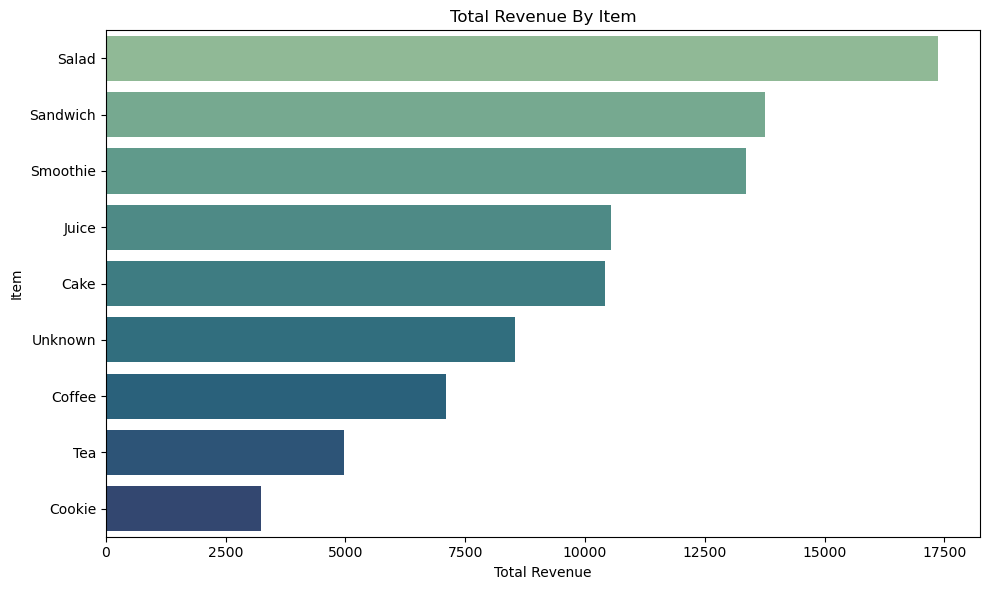

In [6]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=revenue_by_item.values,
    y=revenue_by_item.index,
    palette='crest'
)

plt.title('Total Revenue By Item')
plt.xlabel('Total Revenue')
plt.ylabel('Item')

plt.tight_layout()
plt.show()

#### Salad generates the highest total revenue, followed by Sandwich and Smoothie, while Cookie contributes the lowest revenue. Revenue is unevenly distributed across products, with Salad showing a significantly stronger revenue contribution than lower-performing items.

## Sales Distribution

In [66]:
# Typical transaction value

print("Mean: ", df_cafe['total_spent'].mean())
print("Median: ", df_cafe['total_spent'].median())

Mean:  8.93045
Median:  8.0


In [67]:
# Spread of transaction values

df_cafe['total_spent'].describe()

count    10000.000000
mean         8.930450
std          6.000432
min          1.000000
25%          4.000000
50%          8.000000
75%         12.000000
max         25.000000
Name: total_spent, dtype: float64

In [69]:
# Unusual transcations

cafe_skew = df_cafe['total_spent'].skew()
print("Cafe Skewness: ", cafe_skew)

Cafe Skewness:  0.8206584256372994


#### Visualization - Histogram of Total Revenue

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

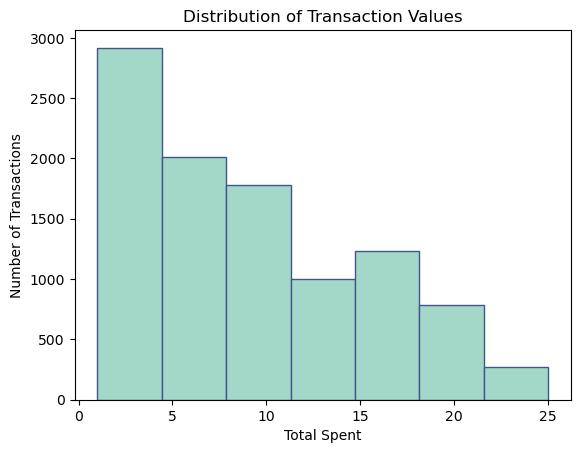

In [82]:
plt.hist(df_cafe['total_spent'], bins=7, edgecolor='#3f568c', color='#a3d8c9')

plt.xlabel('Total Spent')
plt.ylabel('Number of Transactions')
plt.title('Distribution of Transaction Values')
plt.show()

#### Transaction values are concentrated in the lower spending range, with transaction frequency declining as spending increases. This indicates that the cafe primarily serves customers making small-to-moderate purchases, while higher-value transactions occur less frequently.

## Payment Method Analysis

In [93]:
# Transaction count by payment method

transaction_count = df_cafe.groupby('payment_method')['transaction_id'].count().sort_values(ascending=False)
print(transaction_count)

payment_method
Unknown           3178
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: transaction_id, dtype: int64


In [94]:
# Total revenue by payment method

df_cafe.groupby('payment_method')['total_spent'].sum().sort_values(ascending=False)

payment_method
Unknown           27906.5
Credit Card       20502.0
Digital Wallet    20454.5
Cash              20441.5
Name: total_spent, dtype: float64

In [95]:
# Average transaction value by payment method

df_cafe.groupby('payment_method')['total_spent'].mean().sort_values(ascending=False)

payment_method
Cash              9.052923
Credit Card       9.019798
Digital Wallet    8.928197
Unknown           8.781152
Name: total_spent, dtype: float64

#### Visualizations - Payment Method vs Transaction Count

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

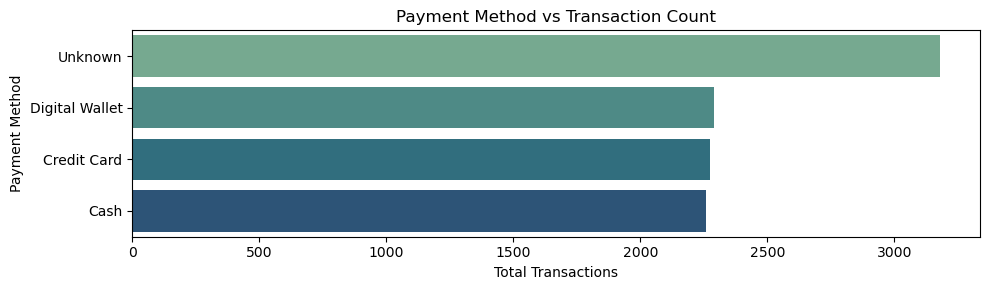

In [96]:
plt.figure(figsize=(10,3))

sns.barplot(
    x=transaction_count.values,
    y=transaction_count.index,
    palette='crest'
)

plt.title('Payment Method vs Transaction Count')
plt.xlabel('Total Transactions')
plt.ylabel('Payment Method')

plt.tight_layout()
plt.show()

#### A substantial proportion of transactions have an unknown payment method, limiting the ability to accurately assess customer payment preferences. Among the identified payment methods, Digital Wallet, Credit Card, and Cash have relatively similar transaction volumes.

## Location Analysis

In [97]:
# Transaction count by location

df_cafe.groupby('location')['transaction_id'].count().sort_values(ascending=False)

location
Unknown     3961
Takeaway    3022
In-store    3017
Name: transaction_id, dtype: int64

In [100]:
# Total revenue by location

location_revenue = df_cafe.groupby('location')['total_spent'].sum().sort_values(ascending=False)
print(location_revenue)

location
Unknown     35435.5
In-store    27256.5
Takeaway    26612.5
Name: total_spent, dtype: float64


In [99]:
# Average transaction value by location

df_cafe.groupby('location')['total_spent'].mean().sort_values(ascending=False)

location
In-store    9.034306
Unknown     8.946099
Takeaway    8.806254
Name: total_spent, dtype: float64

#### Visualization - Location vs Total Revenue

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

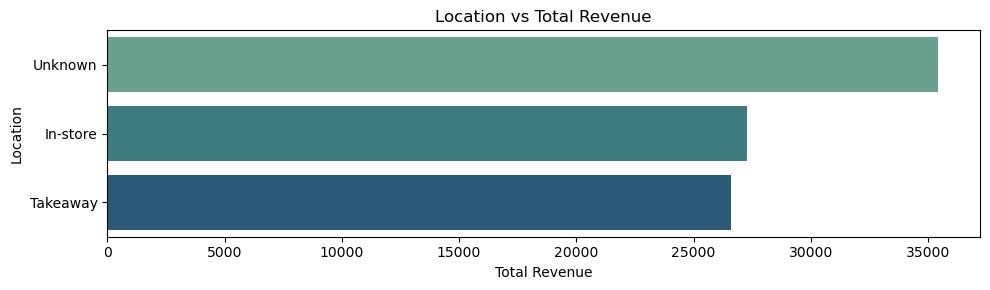

In [101]:
plt.figure(figsize=(10,3))

sns.barplot(
    x=location_revenue.values,
    y=location_revenue.index,
    palette='crest'
)

plt.title('Location vs Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Location')

plt.tight_layout()
plt.show()

#### A substantial portion of revenue is associated with unknown location records, limiting reliable comparison of location-level performance. Among identified locations, In-store generates slightly higher revenue than Takeaway.

## Quantity Analysis

In [ ]:
# Total quantity sold by item

total_quantity_item = df_cafe.groupby('item')['quantity'].sum().sort_values(ascending=False)
print(total_quantity_item)

In [104]:
# Average quantity per transaction by item

df_cafe.groupby('item')['quantity'].mean().sort_values(ascending=False)

item
Smoothie    3.049270
Coffee      3.048069
Cake        3.047410
Sandwich    3.042440
Tea         3.039486
Salad       3.027003
Unknown     3.009288
Juice       3.000854
Cookie      2.965201
Name: quantity, dtype: float64

In [105]:
# Overall quantity distribution

df_cafe['quantity'].describe()

count    10000.000000
mean         3.025800
std          1.420189
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          8.000000
Name: quantity, dtype: float64

#### Visualization - Item vs Total Quantity Sold

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

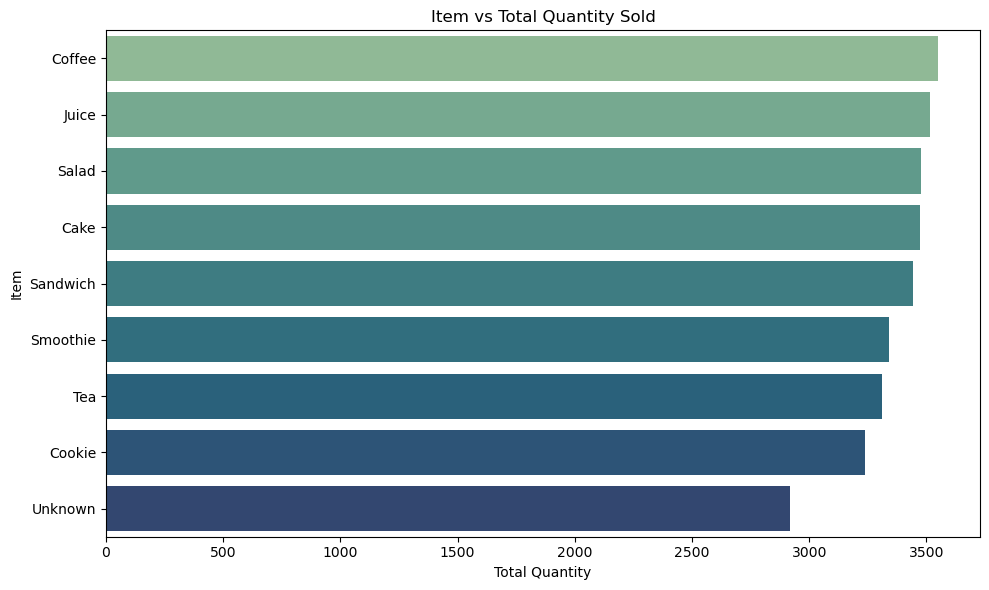

In [107]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=total_quantity_item.values,
    y=total_quantity_item.index,
    palette='crest'
)

plt.title('Item vs Total Quantity Sold')
plt.xlabel('Total Quantity')
plt.ylabel('Item')

plt.tight_layout()
plt.show()

#### Coffee has the highest sales volume, followed by Juice, while Unknown items have the lowest recorded quantity. The similar ranking of quantity and revenue suggests that sales performance is primarily driven by transaction volume rather than major differences in product pricing.

## Time-Based Analysis

In [108]:
# Sales over time

df_cafe.groupby('transaction_date')['total_spent'].sum().sort_index()

transaction_date
2023-01-01    176.0
2023-01-02    189.5
2023-01-03    206.0
2023-01-04    267.5
2023-01-05    363.5
              ...  
2023-12-27    225.0
2023-12-28    175.0
2023-12-29    169.5
2023-12-30    210.0
2023-12-31    187.0
Name: total_spent, Length: 365, dtype: float64

In [109]:
# Transaction volume over time

df_cafe.groupby('transaction_date')['transaction_id'].count().sort_index()

transaction_date
2023-01-01    20
2023-01-02    21
2023-01-03    21
2023-01-04    27
2023-01-05    38
              ..
2023-12-27    24
2023-12-28    21
2023-12-29    25
2023-12-30    27
2023-12-31    20
Name: transaction_id, Length: 365, dtype: int64

In [110]:
# Monthly performance

# Converting date to month
df_cafe['month'] = df_cafe['transaction_date'].dt.to_period('M')

In [118]:
monthly_sales = df_cafe.groupby('month')['total_spent'].sum().sort_index()

In [119]:
print(monthly_sales)

month
2023-01    7284.0
2023-02    6656.0
2023-03    7225.0
2023-04    7203.0
2023-05    7011.5
2023-06    7359.0
2023-07    6885.0
2023-08    7115.5
2023-09    6889.0
2023-10    7326.0
2023-11    6967.0
2023-12    7210.0
Freq: M, Name: total_spent, dtype: float64


#### Visualization - Total Revenue Over Time

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

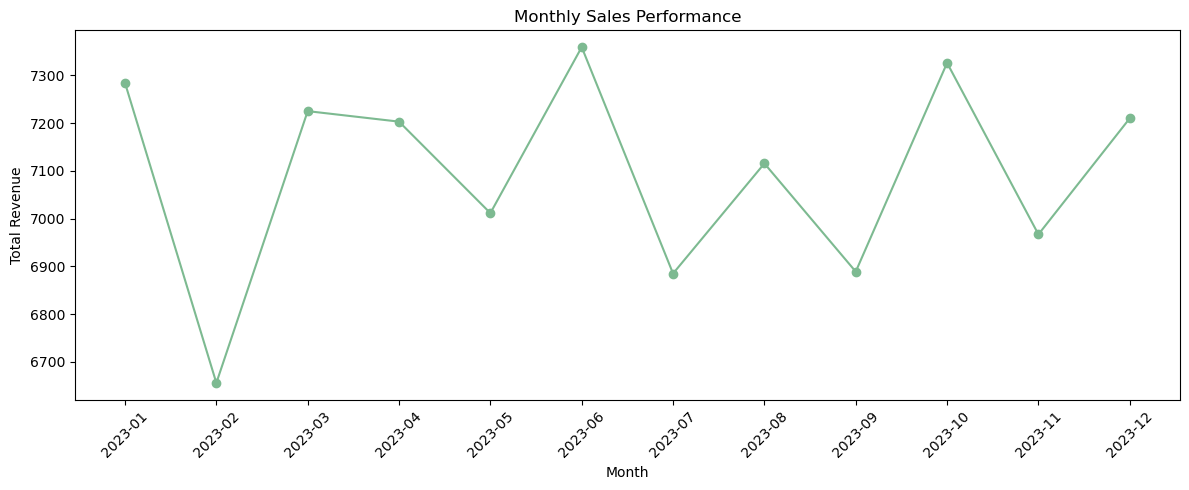

In [121]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales.index.astype(str),
         monthly_sales.values,
         marker='o'
)

plt.title('Monthly Sales Performance')
plt.xlabel('Month')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Monthly revenue fluctuates throughout 2023 without a clear upward or downward trend. June recorded the highest revenue, while February recorded the lowest, indicating periodic variations in sales performance rather than sustained growth.

## Relationship Analysis

In [125]:
# Quantity vs Total Spent

quantity_vs_revenue = df_cafe['quantity'].corr(df_cafe['total_spent'])
print(f'Quantity vs Total Spent = {quantity_vs_revenue}')

Quantity vs Total Spent = 0.7043150872749808


In [126]:
# Price Per Unit vs Total Spent

price_vs_revenue = df_cafe['price_per_unit'].corr(df_cafe['total_spent'])
print(f'Price vs Total Spent = {price_vs_revenue}')

Price vs Total Spent = 0.6468417007330791


In [127]:
# Quantity vs Price Per Unit

quantity_vs_price = df_cafe['quantity'].corr(df_cafe['price_per_unit'])
print(f'Quanity vs Price = {quantity_vs_price}')

Quanity vs Price = 0.007300606168619015


#### Visualization - Quantity vs Total Spent

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

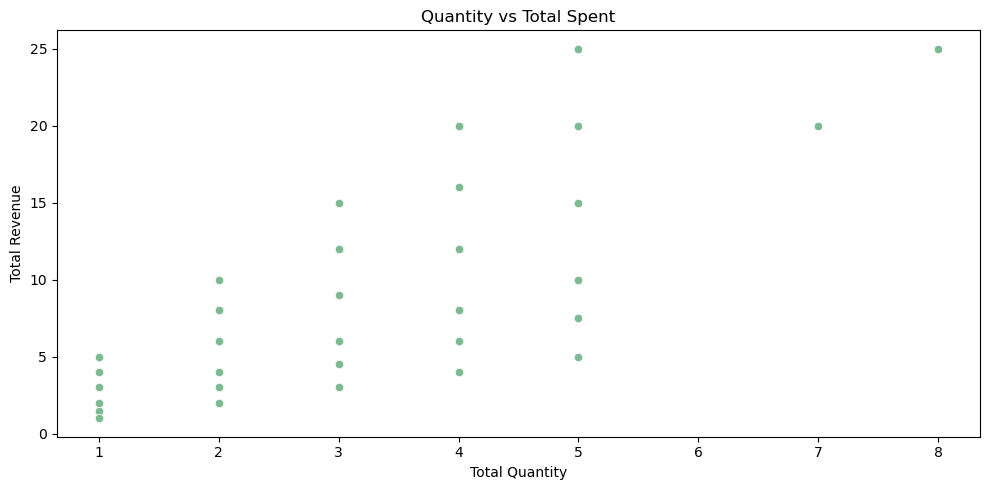

In [123]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df_cafe,
    x='quantity',
    y='total_spent'
)

plt.title('Quantity vs Total Spent')
plt.xlabel('Total Quantity')
plt.ylabel('Total Revenue')

plt.tight_layout()
plt.show()

#### Total spending generally increases with transaction quantity, confirming a positive relationship between the number of items purchased and transaction value. Variations at the same quantity are likely driven by differences in item prices.

## Key Business Insights

#### Product Performance
Salad generated the highest revenue at 17,375 USD, followed by Sandwich at 13,764 USD. However, Coffee recorded the highest sales volume, with 3,551 units sold.

#### Customer Purchasing Behavior
Most transactions are concentrated in the lower spending range, indicating that customers generally make small-to-moderate purchases. Coffee has the highest sales volume, suggesting strong demand for this relatively low-priced product.

#### Operational Performance
A significant number of transactions have unknown payment methods and locations, limiting the ability to accurately analyze customer payment preferences and location-level performance.

#### Sales Trends
Monthly sales fluctuate throughout 2023, with June and October recording the highest revenue and February showing the lowest. The absence of a consistent upward or downward trend suggests periodic fluctuations rather than sustained growth or decline.

#### Quantity vs Total Spent
Higher quantities generally lead to higher transaction values, with transactions involving 4–5 units tending to generate higher spending than transactions involving fewer units. This relationship is also influenced by differences in item prices.